In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

In [7]:
from sklearn.datasets import load_iris 
iris=load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [8]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()
df["Class"]=iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Class              150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB


In [10]:
df[df.duplicated()]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Class
142,5.8,2.7,5.1,1.9,2


In [11]:
# target - class :- categorical ---classification 

In [12]:
# exploring target
df["Class"].value_counts()
# balanced datset

Class
0    50
1    50
2    50
Name: count, dtype: int64

In [13]:
# statistical distribution check 
df.describe()
# +ve skeweness - sepal length (cm)	a little skewess
# -ve skeweness - petal length (cm)	petal width (cm)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Class
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [14]:
# skeweness ,boxplot

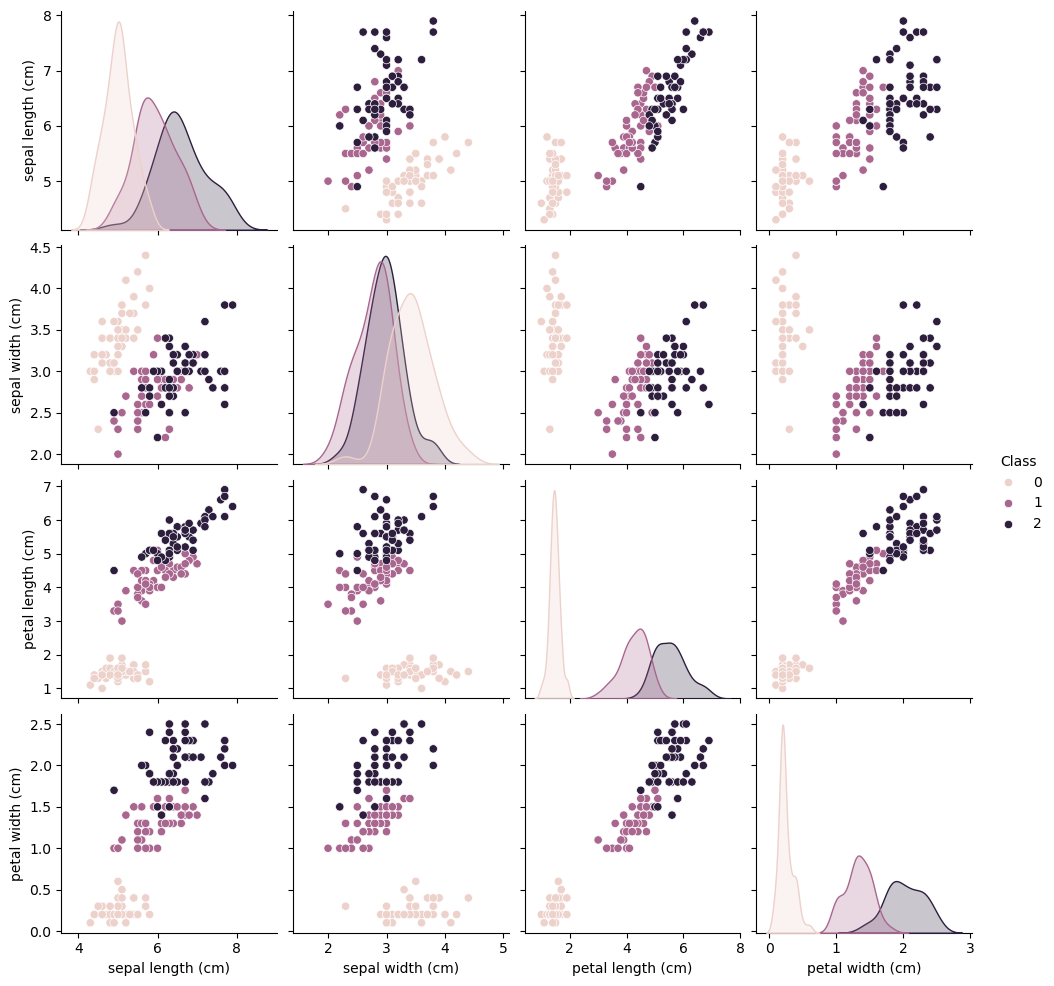

In [15]:
sns.pairplot(df,hue="Class")

<Axes: >

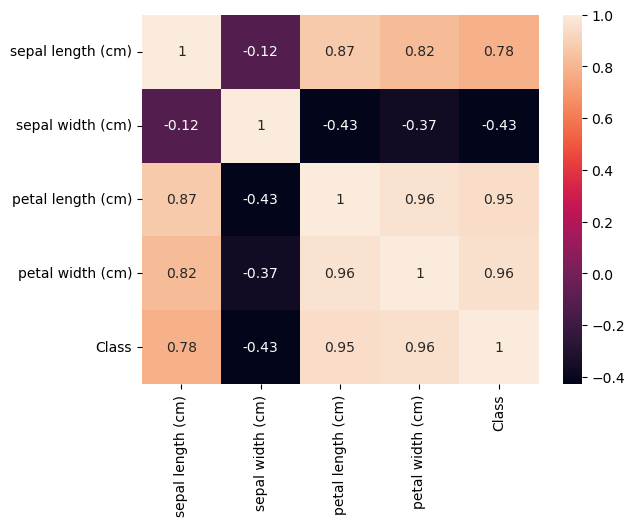

In [16]:
sns.heatmap(df.corr(),annot=True)

In [17]:
features=df.drop("Class",axis=1)
target=df["Class"]

In [18]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain , ytest = train_test_split(features ,target , test_size=0.20,random_state =2)

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,confusion_matrix

In [20]:
def mymodel(model):
    model.fit(xtrain,ytrain)
    ypred=model.predict(xtest)
    # checking for overfit and underfit 
    print(f"Training Score : {model.score(xtrain,ytrain)}")
    print(f"Testing score : {model.score(xtest,ytest)}")
    # evalution metrics
    c=pd.DataFrame(confusion_matrix(ytest,ypred),
                  index=["Setosa","Versicolor","Virginica"],
                   columns=["Setosa","Versicolor","Virginica"])
    print(f"Confusion Matric:\n{c}")
    print(f"Classification report :\n{classification_report(ytest,ypred)}")
    return model
    

In [21]:
mymodel(DecisionTreeClassifier())

Training Score : 1.0
Testing score : 0.9333333333333333
Confusion Matric:
            Setosa  Versicolor  Virginica
Setosa          14           0          0
Versicolor       0           7          1
Virginica        0           1          7
Classification report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.88      0.88      0.88         8
           2       0.88      0.88      0.88         8

    accuracy                           0.93        30
   macro avg       0.92      0.92      0.92        30
weighted avg       0.93      0.93      0.93        30



DecisionTreeClassifier()

In [22]:
dt=mymodel(DecisionTreeClassifier())
dt

Training Score : 1.0
Testing score : 0.9333333333333333
Confusion Matric:
            Setosa  Versicolor  Virginica
Setosa          14           0          0
Versicolor       0           7          1
Virginica        0           1          7
Classification report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.88      0.88      0.88         8
           2       0.88      0.88      0.88         8

    accuracy                           0.93        30
   macro avg       0.92      0.92      0.92        30
weighted avg       0.93      0.93      0.93        30



DecisionTreeClassifier()

In [23]:
d={"Features":iris.feature_names,
   "Importance":dt.feature_importances_
  }
f=pd.DataFrame(d)
f

,Features,Importance
0,sepal length (cm),0.000000
1,sepal width (cm),0.018797
2,petal length (cm),0.056904
3,petal width (cm),0.924299


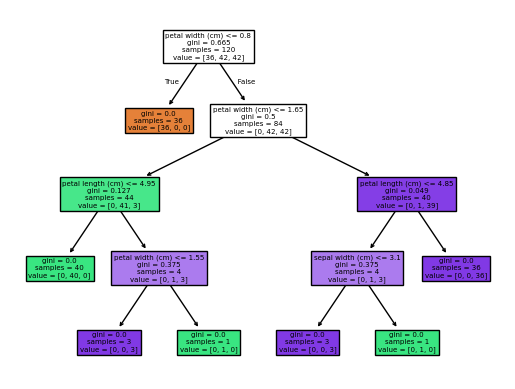

In [24]:
from sklearn import tree
tree.plot_tree(dt,feature_names=iris.feature_names,filled=True)
plt.show()

In [25]:
dt.get_depth()

4

In [26]:
dt.get_n_leaves()

7

In [27]:
# to deal with overfitting apply pruning techniques
parameters={
    "max_depth":list(range(2,3)),
    "min_samples_split":list(range(2,4)),
    "min_samples_split":list(range(2,4))
}

In [28]:
from sklearn.model_selection import GridSearchCV
clf=GridSearchCV(DecisionTreeClassifier(),parameters,verbose=2)
clf.fit(xtrain,ytrain)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
[CV] END ...................max_depth=2, min_samples_split=2; total time=   0.0s
[CV] END ...................max_depth=2, min_samples_split=2; total time=   0.0s
[CV] END ...................max_depth=2, min_samples_split=2; total time=   0.0s
[CV] END ...................max_depth=2, min_samples_split=2; total time=   0.0s
[CV] END ...................max_depth=2, min_samples_split=2; total time=   0.0s
[CV] END ...................max_depth=2, min_samples_split=3; total time=   0.0s
[CV] END ...................max_depth=2, min_samples_split=3; total time=   0.0s
[CV] END ...................max_depth=2, min_samples_split=3; total time=   0.0s
[CV] END ...................max_depth=2, min_samples_split=3; total time=   0.0s
[CV] END ...................max_depth=2, min_samples_split=3; total time=   0.0s


GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [2], 'min_samples_split': [2, 3]},
             verbose=2)

In [29]:
clf=mymodel(clf.best_estimator_)
clf

Training Score : 0.9666666666666667
Testing score : 0.9333333333333333
Confusion Matric:
            Setosa  Versicolor  Virginica
Setosa          14           0          0
Versicolor       0           7          1
Virginica        0           1          7
Classification report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.88      0.88      0.88         8
           2       0.88      0.88      0.88         8

    accuracy                           0.93        30
   macro avg       0.92      0.92      0.92        30
weighted avg       0.93      0.93      0.93        30



DecisionTreeClassifier(max_depth=2)

In [30]:
f["After pruning Importance"] = clf.feature_importances_
f

,Features,Importance,After pruning Importance
0,sepal length (cm),0.000000,0.000000
1,sepal width (cm),0.018797,0.000000
2,petal length (cm),0.056904,0.523118
3,petal width (cm),0.924299,0.476882


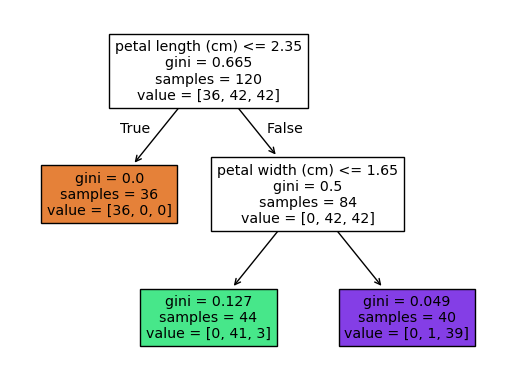

In [31]:
from sklearn import tree
tree.plot_tree(clf,feature_names=iris.feature_names,filled = True)
plt.show()

pruning techniques and decision trees overfit easily because they keep spliting until they perfectly feet traning data for achiving this tree becomes very complex so the pruning techniques are applied to control the tree complexity. the pre pruning techniques stops the tree before it gross to deep the comon parameters are 
1) "max_depth" control maximum depth of the tree.
2) min_sample_split : minimum sample to be present to slipt a node
3) "minimum_sample_leafs" : controls minimum number of samples to be present in a leaf
4) "max_leaf_node": controls maximum number of leaf nodes

GridSerchCV searches fro the best hyper paramaters using cross validation it prevants overfitting try to find the optimal model which is not to complex and use validation folds and not test data. it evaluates model on unseen folds panalies over complex tress and choose the parameters with best generalization.

ensableled techniques combines multiple model to build a strong more stable prediction many weak learnaers gives one strong learner is a key principle 
types of ensabled techniques : bagging, trains multiple models independently and each model is trained on a sample with replacement also called as bootstrap samples the final prediction is the average or the measurity vote based on regrassion or classification that is why bagging is also called as bootstrap aggrigation its goal is to reduce varince

boosting : boosting here the models are train sequesncially and each model focusses on fixing the previous errors by giving higher weight to the wrong or error done urliear

Random forest is a bagging of dicision tress on randomly selected features each tree gets random rows and random subset of features of each split beacuse of which the trees become less correlated and hence the variance goes down and performance incrase. its key parameters are:
1) "max_depth" control maximum depth of the tree.
2) min_sample_split : minimum sample to be present to slipt a node
3) "minimum_sample_leafs" : controls minimum number of samples to be present in a leaf
4) "max_leaf_node": controls maximum number of leaf nodes
5) also n_estimaters this are the number of trees by default they are 100 also max_fetures this are the maximum number of features to concider number of features
its advantages are :
1) it handles non-linearity
2) it is robhust to noice and gives feature imporatance by giving avergae dicress in impurity
its disadvatages are:
1) it is less explainable and slower 

In [35]:
import pickle
with open("model.pkl","wb") as f:
    pickle.dump(clf,f)